## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [2]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_y1985.1y_gridT.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979.nc'

# NEMO full grid coords
filepath_domain_cfg = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# Set the filepaths 
# The target grid mask 
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
filepath_mask = '/bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc'
# The target grid geometry
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'
filepath_domain_CFG = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# And the location of the output files 
folder_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM002' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 
filepath_nn_output = folder_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = False
nemo_version = '5'

## Apply neural network

In [3]:
import time

In [4]:
%%time
apply_nn_to_NEMO(filepath_nemo_output, 
                     filepath_mask, 
                     filepath_geomvars, 
                     filepath_eORCA1_bmach_masks, 
                     filepath_domain_CFG,
                     path_model, 
                     path_norm_metrics, 
                     filepath_nn_output, 
                     this_collection, 
                     exp_name, 
                     join_ice_shelves, 
                     verbose = 0, 
                     nemo_version = nemo_version)

You have loaded: /bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc
You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
You have loaded T and S: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
Loaded data. Time: 4.6 s
There are 11 basins with no ocean profiles : [16, 27, 28, 31, 34, 39, 43, 80, 107, 115, 126]
There should be 5 basins (2 with no cavities plus 3 where we merged)
Created T/S profiles. Time: 12.2 s
Prepared data to apply NN. Time: 18.5 s
Applying neural networks
Applied NN. Time: 25.5 s               
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
Returning area
Putting melt back onto the ocean grid
Propagated melt to 

## Look at the resulting melt distribution map for NEMO

Maximum refreezing is      : -1.9789817538996098e-06
Maximum melting is: 0.0050916287330931825


/tmp/ipykernel_33101/3624774748.py:9: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-melt_all), cmap = 'Blues')
/tmp/ipykernel_33101/3624774748.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = -0.08)
/tmp/ipykernel_33101/3624774748.py:14: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
/tmp/ipykernel_33101/3624774748.py:16: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


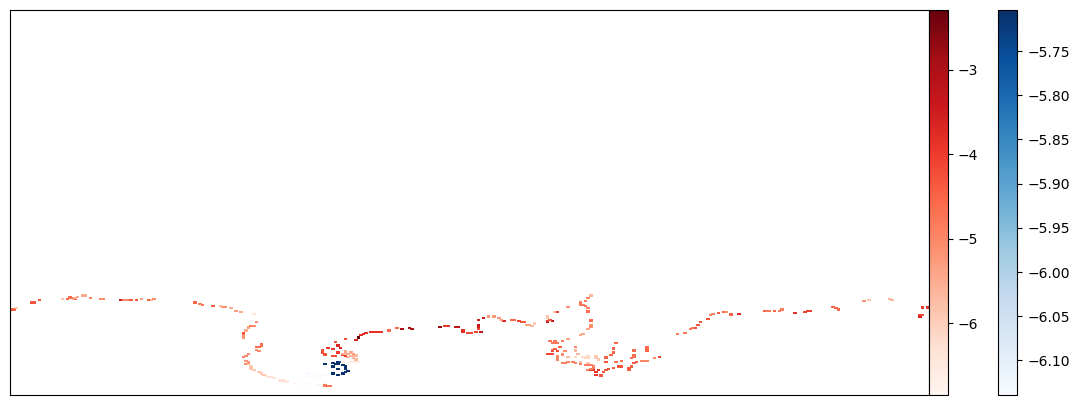

In [5]:
melt = xr.open_dataset(filepath_nn_output)# + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan

print('Maximum refreezing is      :', np.nanmin(melt_all))
print('Maximum melting is:', np.nanmax(melt_all))

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Blues')
#im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
#cbar.set_ticks((-5,-4,-3,-2))
#cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
#im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
#cbar.set_ticks((-5,-4,-3,-2))
#cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
#ax.set_ylim(0,110)

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')

In [6]:
purple

NameError: name 'purple' is not defined

# A more in depth look at what is happening in the apply_nn_to_NEMO function

### Load in the NEMO data, masks associated, and the target grid for the NN

In [9]:
filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc'

In [10]:
gridT_varofint = xr.open_dataset(filepath_nemo_output)
print('You have loaded T and S:', filepath_nemo_output)
# And cut out variables which are not needed
gridT_varofint = gridT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop('time_counter').drop('time_centered')
# Crop out most of the world and just save Antarctica 
# Specify the coordinates needed
min_lat = -52.2
y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
print('Cropped to Antarctica only')
# Take this slice 
#gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))[['thetao','so', 'area', 'bathy', 'isf_draft']]
gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))
gridT2 = normalise_variable_names(gridT2)
gridT2 = gridT2[['thetao', 'so']]#, 'area']]
# Close the original dataset
so = gridT2.so
thetao = gridT2.thetao

You have loaded T and S: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc
Cropped to Antarctica only


/tmp/ipykernel_33101/943433968.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  gridT_varofint = gridT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop('time_counter').drop('time_centered')


In [11]:
print('Minimum salinity is:', np.nanmin(so.values))
print('Maximum salinity is:', np.nanmax(so.values))

Minimum salinity is: 13.887327
Maximum salinity is: 35.08744


In [12]:
# Load in the TS grid 
gridT2 = load_TSmelt_normal(filepath_nemo_output)
# Load in the mask for the ocean region 
bmach_masks = xr.open_dataset(filepath_eORCA1_bmach_masks)
mask_nocavs = bmach_masks.mask_nocavs.values
bmach_masks.close()

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, 
                                              filepath_mask, 
                                              join_ice_shelves = join_ice_shelves)
# Rename the dimensions of basins merged to be x and y 
if 'y_grid_T' in basins_merged.dims:
    basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)
# The basins mask for the NEMO 025 grid  
basins_NEMO = masks.basins_NEMO.values
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos = np.arange(1,156, dtype = 'float32')
basin_nos = np.unique(basins_NEMO)

You have loaded T and S: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc
Cropped to Antarctica only
You have loaded: /bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc
You have loaded coordinates: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc
Cropped to Antarctica only


### Create a list of the cells where it is okay to extract ocean profiles 

In [13]:
# Regions where it is acceptable to extract ocean profiles 
iy, ix = np.where((mask_nocavs == 1))
# coordinates of those cells
lat_ocean = coords.nav_lat.values[iy, ix]
lon_ocean = coords.nav_lon.values[iy, ix]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
# Stack to prepare for the KDTree
ocean_points = np.column_stack((x_ocean, y_ocean))
# Create KDTree
tree = cKDTree(ocean_points)

In [14]:
plot_basin_nos_map = False
if plot_basin_nos_map == True:
    fig, ax = plt.subplots(1,1, figsize = (10,8))
    for kk in range(len(basin_nos)):
        i = basin_nos[kk]
        mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        if len(x_cavs) > 0:
            plt.scatter(np.mean(x_cavs), np.mean(y_cavs), s = 40, c = 'skyblue')
        if np.mod(i,2) == 1: 
            plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*1.04, np.mean(y_cavs)*1.04), fontsize = 8, ha = 'center', va = 'center')
        else:
          plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*0.96, np.mean(y_cavs)*0.96), fontsize = 8, ha = 'center', va = 'center')  
    ax.axis('off');

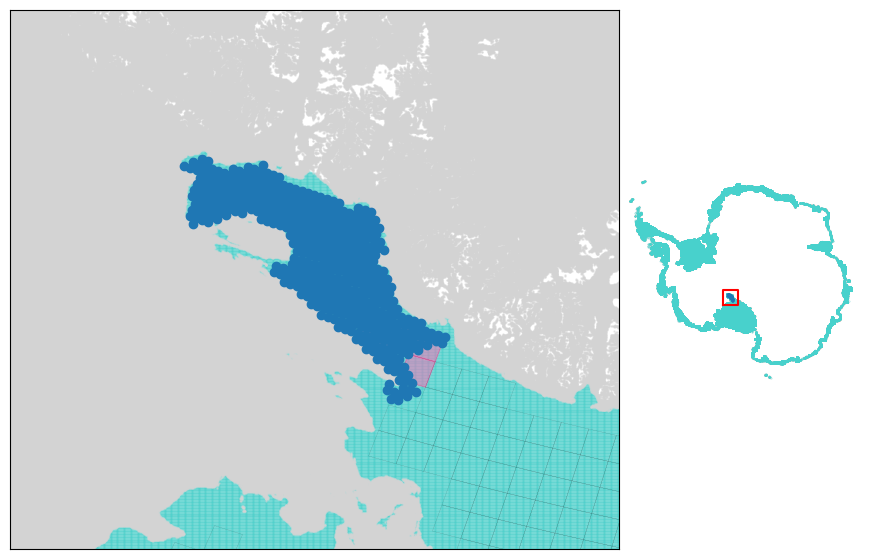

In [15]:
# To look at which ocean cells are extracted for each individual basin
plot_figure = True
if plot_figure == True:
    #kk = 100
    #i = basin_nos[kk]
    #i = 104 #(A good example where it comes around the corner)
    i = 125 ## AAAAh George VI
    i = 55
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    ocean_edge_illus = np.zeros_like(mask_nocavs)
    # If you allow all the nearest cells
    # And fill the cells found with the kd-tree
    for k in range(len(idx)):
        ocean_edge_illus[iy[idx[k]], ix[idx[k]]] = 1

    # Only allow cells where the distance is less than 1.5 times the minimum distance 
    # Should allow cells which are adjacent or as close to adjacent as possible
    idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
    for k in range(len(idxn)):
        ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    
    # Convert to polar stereographic coordinates 
    coords_x, coords_y = transformer.transform(coords.nav_lat, coords.nav_lon)
    # Calculate mean and range of cavity points
    mean_xcavs, mean_ycavs = np.mean(x_cavs), np.mean(y_cavs)
    rang_xcavs, rang_ycavs = np.max(x_cavs) - np.min(x_cavs), np.max(y_cavs) - np.min(y_cavs)
    rang = np.max((rang_xcavs, rang_ycavs))
    if rang < 500000:
        rang = 500000
    # Create mask of the relevant region)
    mask_close = (coords_x < (np.max(x_cavs) + rang*0.3)) & (coords_x > (np.min(x_cavs) - rang*0.3)) & \
                 (coords_y < (np.max(y_cavs) + rang*0.3)) & (coords_y > (np.min(y_cavs) - rang*0.3)) 
    
    # Ocean cells 
    iy2, ix2 = np.where(ocean_edge_basin == 1)
    x_oceanhere = []
    y_oceanhere = []
    for jkl in (0,1,2,3,0):
        lat_oceanhere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy2, ix2]
        lon_oceanhere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy2, ix2]
        x_jkl, y_jkl = transformer.transform(lat_oceanhere, lon_oceanhere)
        x_oceanhere.append(x_jkl)
        y_oceanhere.append(y_jkl)
    # Ocean cells with old code  
    iy5, ix5 = np.where(ocean_edge_illus == 1)
    x_illushere = []
    y_illushere = []
    for jkl in (0,1,2,3,0):
        lat_illushere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy5, ix5]
        lon_illushere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy5, ix5]
        x_jkl, y_jkl = transformer.transform(lat_illushere, lon_illushere)
        x_illushere.append(x_jkl)
        y_illushere.append(y_jkl)
    
    # All Bedmachine cells 
    iy3, ix3 = np.where((mask_close == 1) & (mask_nocavs == 1)) 
    x_grid = []
    y_grid = []
    for jkl in (0,1,2,3,0):
        lat_here = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy3, ix3]
        lon_here = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy3, ix3]
        x_jkl, y_jkl = transformer.transform(lat_here, lon_here)
        x_grid.append(x_jkl)
        y_grid.append(y_jkl)
    
    # Load in the bedmachine data for plotting
    # Filepath_bedmachine 
    filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'
    bmach3 = xr.open_dataset(filepath_bedmachine)
    xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
    
    fig, axs = plt.subplots(1,2, figsize = (11,7), width_ratios = (2.5,1))
    plt.subplots_adjust(wspace = 0)
    
    ax = axs[0]
    ax.fill(x_oceanhere, y_oceanhere, c = 'hotpink', zorder = 2, alpha = 0.5);
    #ax.fill(x_illushere, y_illushere, c = 'lightpink', zorder = 1, alpha = 0.5);
    ax.plot(x_grid, y_grid, c = 'k', linewidth = 0.1, zorder = 10, alpha = 0.5);
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    value = 2
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'lightgrey', \
              label = '', zorder = 0, alpha = 0.5)
    value = 0
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'paleturquoise', \
              label = 'Ocean', zorder = 0, alpha = 0.5)
    #ax.axis('equal')
    ax.set_xlim(np.min(x_cavs)-rang*0.2, np.max(x_cavs) + rang*0.2)
    ax.set_ylim(np.min(y_cavs)-rang*0.2, np.max(y_cavs) + rang*0.2)
    
    ax.scatter(x_cavs, y_cavs, zorder = 10)
    ax.set_xticks([]), ax.set_yticks([])
    
    ax = axs[1]
    ax.scatter(x_cavs, y_cavs, s = 0.05)
    ax.plot((np.min(x_cavs) - rang*0.2, np.min(x_cavs) - rang*0.2, \
             np.max(x_cavs) + rang*0.2, np.max(x_cavs) + rang*0.2, \
             np.min(x_cavs) - rang*0.2), \
            (np.min(y_cavs) - rang*0.2, \
             np.max(y_cavs) + rang*0.2, np.max(y_cavs) + rang*0.2, \
             np.min(y_cavs) - rang*0.2, np.min(y_cavs) - rang*0.2), c = 'red')
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.05, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    ax.axis('equal')
    ax.set_xticks([]), ax.set_yticks([])
    ax.axis('off')
    
    fig.savefig('FIGURES/howtoselectoceancells.jpg', dpi = 200, bbox_inches = 'tight')

In [16]:
verbose = 2

In [17]:
# For each basin in basin_nos, create a mask of the ocean profiles to extract 
profiles_all = []
i_no_value = []
basins_all_temp = np.zeros_like(mask_nocavs)
for kk in range(len(basin_nos)):
    i = basin_nos[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    # Should allow cells which are adjacent or as close to adjacent as possible
    if len(idx) == 1:
        for k in range(len(idx)):
            ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    elif len(idx) != 0:
        idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
        for k in range(len(idxn)):
            ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    else:
        # Calculate which basins don't have profiles
        i_no_value.append(int(i))
    ### This is only needed if you want to look at which ocean cells will recieve melt from many basins   
    basins_all_temp = basins_all_temp + ocean_edge_basin
    
    # Use the mask to extract the relevant profiles 

    masked_depth = gridT2.where(ocean_edge_basin == 1)
    profiles = masked_depth.stack(points=("x", "y"))
    profiles = profiles.dropna(dim="points", how="all")
    #profiles = profiles.drop_vars(["area", "bathy", "isf_draft"]) 
    # Fill the nan values in the profile
    profile_kk = profiles.mean(dim = 'points').interpolate_na(dim = 'deptht').ffill('deptht').bfill('deptht')
    # Add a coordinate for kk
    profile_kk = profile_kk.expand_dims(kk =[int(i)])
    #profile_kk = profile_kk.expand_dims(kk_m1 =[int(i)-1])
    profiles_all.append(profile_kk)
    if verbose == 1:
        print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')
# Concatenate the profiles along the new dimension
all_profiles = xr.concat(profiles_all, dim="kk")

print('There are {} basins with no ocean profiles : {}'.format(len(i_no_value), i_no_value))
print('There should be 5 basins (2 with no cavities plus 3 where we merged)')
#print('There should be 17 basins (14 with no cavities plus 3 where we merged)')

There are 11 basins with no ocean profiles : [16, 27, 28, 31, 34, 39, 43, 80, 107, 115, 126]
There should be 5 basins (2 with no cavities plus 3 where we merged)


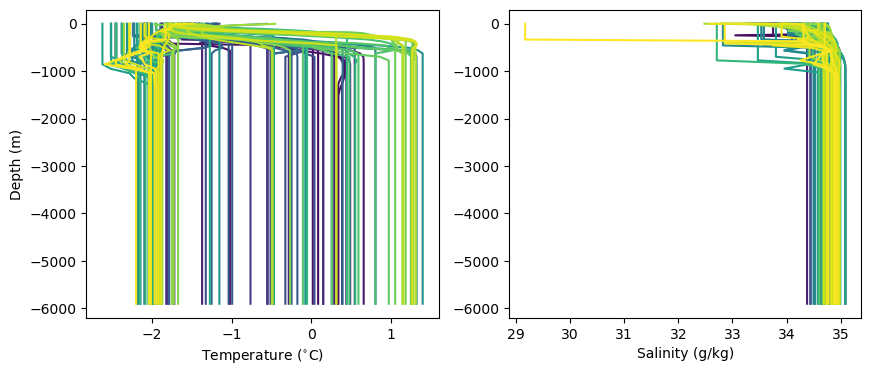

In [18]:
plot_profile = True
if plot_profile == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    for kk in all_profiles.kk.values:
        profile = all_profiles.sel(kk=kk)
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
        ax[1].plot(profile.so, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
    ax[0].set_ylabel('Depth (m)');
    #ax[1].set_ylabel('Depth (m)')
    ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
    ax[1].set_xlabel('Salinity (g/kg)');
fig.savefig('profile.jpg', dpi = 200, bbox_inches = 'tight')

In [19]:
# Extract the relevant values of temperature and salinity 
temp_xy = all_profiles.thetao.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
temp_xy = temp_xy.reset_coords(drop=True)
sals_xy = all_profiles.so.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
sals_xy = sals_xy.reset_coords(drop=True)

# Calculate mean and standard deviation by region
# Note: this step produces an error because some basins have nan mean, but the code still runs so it's okay?
meanT_by_region = temp_xy.groupby(basins_merged).mean()
stdT_by_region  = temp_xy.groupby(basins_merged).std()
meanS_by_region = sals_xy.groupby(basins_merged).mean()
stdS_by_region  = sals_xy.groupby(basins_merged).std()
# and send back to the original grid 
mean_T = meanT_by_region.sel(basins_NEMO = basins_merged)
std_T = stdT_by_region.sel(basins_NEMO = basins_merged)
mean_S = meanS_by_region.sel(basins_NEMO = basins_merged)
std_S = stdS_by_region.sel(basins_NEMO = basins_merged)
# Reset the coordinates
mean_T = mean_T.reset_coords(drop=True)
mean_S = mean_S.reset_coords(drop=True)
std_T = std_T.reset_coords(drop=True)
std_S = std_S.reset_coords(drop=True)

/tmp/ipykernel_33101/3945807193.py:14: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)


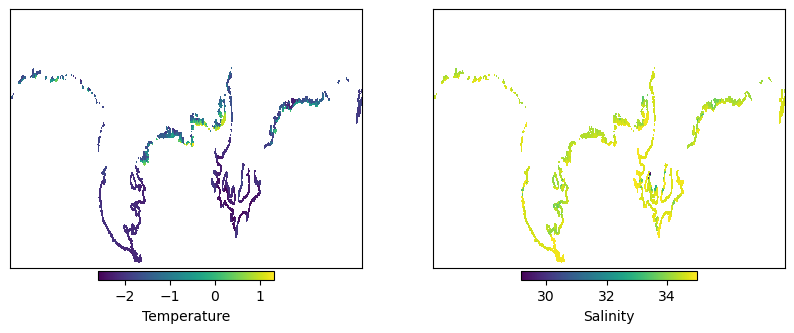

In [20]:
plot_figure = True
if plot_figure == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    #closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    closed_cavs = masks.closed_cavities_nan#.rename({"y_grid_T": "y", "x_grid_T": "x"})
    im = [[],[]]
    # Note that using pcolor rather than pcolormesh leads to the error
    im[0] = ax[0].pcolor(temp_xy*closed_cavs)
    im[1] = ax[1].pcolor(sals_xy*closed_cavs)
    labels = 'Temperature', 'Salinity'
    for i in range(2):
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)
        cbar.set_label(labels[i])
fig.savefig('Propagated.jpg',dpi= 200, bbox_inches = 'tight')

In [21]:
# Create the input dataset for the neural network to be applied to
ds = geoms.rename({"areas": "area",
                   "isf_draft": "corrected_isdraft",
                   "slope_isdraft_lon": "slope_is_lon",
                   "slope_isdraft_lat": "slope_is_lat",
                   "slope_bathy_lon": "slope_ba_lon",
                   "slope_bathy_lat": "slope_ba_lat",})
ds = ds.assign(temperature_prop = temp_xy,
                  mean_T           = mean_T,
                  std_T            = std_T,
                  salinity_prop    = sals_xy,
                  mean_S           = mean_S,
                  std_S            = std_S,
                  basins_NEMO      = basins_merged,)
ds.attrs["description"] = "Neural network input variables"

In [22]:
# Rename variables in closed cavity mask 
if 'y_grid_T' in basins_merged.dims:
    closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
else:
    closed_cavs = masks.closed_cavities_nan
# Select only the points in the closed cavity regions
stacked = ds.where(closed_cavs == 1).stack(points=("x", "y")).dropna("points", how = "all")
# and convert to a pandas dataframe
selected = stacked.to_dataframe().reset_index().drop(columns=["x", "y"])
# Remove nan values (although still unclear why there are nan values)
selected = selected[~np.isnan(selected.temperature_prop)]

In [23]:
def apply_10nns(exp_name, this_collection, clean_df, path_model, path_norm_metrics, 
                       mod_size = 'small', 
                         TS_opt = 'extrap', 
                    norm_method = 'std', 
                        verbose = 0, 
                    annual_only = False, 
               apply_collection = None, 
                       annual_f = ''):
    # Load in the normalisation metrics 
    norm_metrics = load_normalisation_metrics(this_collection, path_norm_metrics, norm_method = 'std', verbose = 0)
    # Extract the values that you might want from the clean dataframe
    df_pred = pd.DataFrame({'lat'   : clean_df.lat, 
                            'lon'   : clean_df.lon,
                            'basin' : clean_df.basins_NEMO,
                            'area'  : clean_df.area, 
                            'fraction' : clean_df.fraction})
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    start_time = time.time()
    for i in range(len(seed_nb_array)):
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
    
        model = load_model_nn(exp_name, this_collection, path_model, seed_nb_array[i], \
                                  mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                                  verbose = verbose, annual_f = annual_f) 
        df_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = verbose)
        end_time = time.time()
        print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.1f} s'.format(end_time - start_time), end = '\r')
    # Calculate the ensemble mean 
    df_pred['mean_melt'] = np.mean(df_pred[list_melt_seeds], axis = 1).values
    if verbose == 1:
        print('Maximum melt rate: {:.5f} '.format(np.min(df_pred.mean_melt.values)))
        print('Minimum melt rate: {:.5f} '.format(np.max(df_pred.mean_melt.values)))
        print('Mean melt rate: {:.5f} '.format(np.mean(df_pred.mean_melt.values)))
    # And the standard deviation 
    df_pred['std_melt'] = np.std(df_pred[list_melt_seeds], axis = 1).values
    #df_pred.loc[:,'melt_Gt'] = df_pred.mean_melt * (60*60*24*365.25)/917
    df_pred.loc[:,'melt_Gt'] = df_pred.mean_melt * df_pred.area * df_pred.fraction * 31536000 * 1/1e12
    # Save just the ensemble mean/std
    #df_save = df_pred.copy()[['lat','lon', 'basin', 'area', 'mean_melt', 'std_melt', 'melt_Gt']]
    # Save just the melt by basin/
    melt = df_pred
    melt_by_basin = df_pred.groupby('basin', as_index = False).sum()[['basin','melt_Gt']]
    #lat_lon_by_basin = df_pred.groupby('basin', as_index = False).mean()[['lat','lon']]
    return melt, melt_by_basin

In [24]:
# Apply all 10 neural networks 
print('Applying neural networks')
melt, melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)

Applying neural networks


In [25]:
melt['x'], melt['y'] = transformer.transform(melt.lat, melt.lon)
melt

,lat,lon,basin,area,fraction,melt_01,melt_02,melt_03,melt_04,melt_05,melt_06,melt_07,melt_08,melt_09,melt_10,mean_melt,std_melt,melt_Gt,x,y
0,-69.851738,73.00,94.0,9.169279e+07,1.0,-0.000012,-0.000010,-0.000002,-0.000002,-0.000013,-0.000016,-3.667840e-07,-0.000013,-0.000016,-0.000012,-0.000010,0.000006,-0.027548,2.114474e+06,646459.554401
1,-69.765450,73.00,94.0,9.244687e+07,1.0,-0.000012,-0.000017,-0.000010,-0.000018,-0.000016,-0.000029,-1.803563e-05,-0.000031,-0.000018,-0.000013,-0.000018,0.000007,-0.053349,2.123713e+06,649284.130816
2,-69.678802,73.00,94.0,9.320673e+07,1.0,-0.000042,-0.000028,-0.000021,-0.000039,-0.000014,-0.000033,-2.570140e-05,-0.000027,-0.000020,-0.000019,-0.000027,0.000009,-0.078693,2.132992e+06,652121.180294
3,-69.765450,73.25,94.0,9.244687e+07,1.0,-0.000012,-0.000013,-0.000002,-0.000009,-0.000017,-0.000026,-6.562519e-06,-0.000017,-0.000017,-0.000020,-0.000014,0.000007,-0.040776,2.126526e+06,640011.534760
4,-69.678802,73.25,94.0,9.320673e+07,1.0,-0.000017,-0.000025,-0.000021,-0.000034,-0.000016,-0.000038,-2.276035e-05,-0.000034,-0.000021,-0.000011,-0.000024,0.000008,-0.070379,2.135817e+06,642808.067593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11334,-69.765450,72.75,94.0,9.244687e+07,1.0,-0.000012,-0.000024,-0.000019,-0.000032,-0.000013,-0.000047,-2.050419e-05,-0.000034,-0.000024,-0.000011,-0.000024,0.000011,-0.068795,2.120859e+06,658544.365439
11335,-69.062279,72.75,94.0,9.869061e+07,1.0,-0.000009,-0.000013,-0.000028,-0.000015,-0.000018,-0.000026,-2.534993e-05,-0.000032,-0.000027,-0.000037,-0.000023,0.000009,-0.071897,2.196136e+06,681918.255792
11336,-68.972763,72.75,94.0,9.949802e+07,1.0,-0.000007,-0.000014,-0.000033,-0.000017,-0.000024,-0.000023,-2.584547e-05,-0.000025,-0.000024,-0.000031,-0.000022,0.000007,-0.070265,2.205730e+06,684897.446222
11337,-68.882874,72.75,94.0,1.003115e+08,1.0,-0.000005,-0.000023,-0.000036,-0.000019,-0.000031,0.000009,-3.165606e-05,-0.000011,-0.000017,-0.000032,-0.000020,0.000014,-0.062325,2.215368e+06,687889.915418


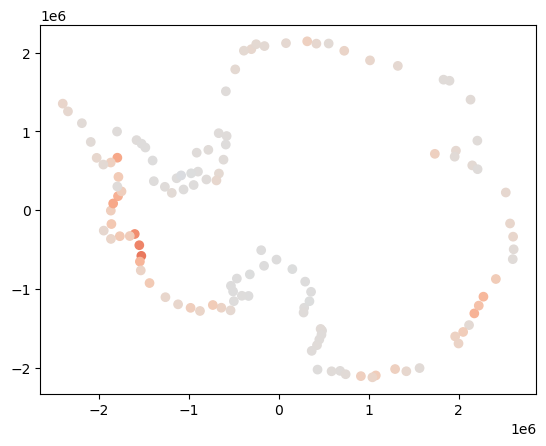

In [26]:
melt_mean = melt.groupby('basin', as_index = False).mean()
im = plt.scatter(melt_mean.x, melt_mean.y, c = melt_mean.mean_melt, cmap = 'coolwarm_r')
im.set_clim(-0.0008,0.0008)

In [27]:
THW = melt[melt.basin == 77.0]# & melt.basin == 94.0 & melt.basin == 18]

3.146701504269635 -0.18241935571869156


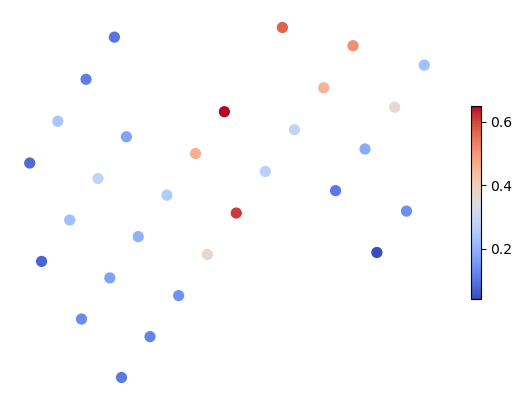

In [28]:
fig, ax = plt.subplots(1,1, figsize = (7,5))
ds_plt = THW
ax.axis('off');
im = plt.scatter(ds_plt.x, ds_plt.y, c = -ds_plt.melt_Gt, s = 50, cmap = 'coolwarm')
print(-np.min(melt.melt_Gt), -np.max(melt.melt_Gt))
#im.set_clim(np.nanmin(ds_plt.mean_melt),-np.nanmin(ds_plt.mean_melt))
#im.set_clim(-4,4)
#ax.set_xlim(-2e6,-1e6)
#ax.set_ylim(-1e6,0e6)
plt.colorbar(im, shrink = 0.5)

0.002061659708741043 -4.9448167116073805e-05


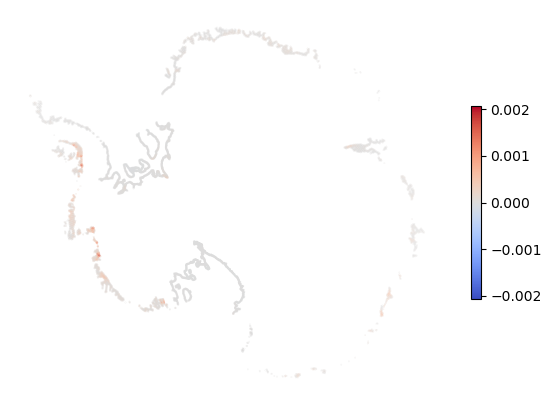

In [29]:
fig, ax = plt.subplots(1,1, figsize = (7,5))
ax.axis('off');
im = plt.scatter(melt.x, melt.y, c = -melt.mean_melt, s = 0.01, cmap = 'coolwarm')
print(-np.min(melt.mean_melt), -np.max(melt.mean_melt))
im.set_clim(np.nanmin(melt.mean_melt),-np.nanmin(melt.mean_melt))
#im.set_clim(-4,4)
#ax.set_xlim(-2e6,-1e6)
#ax.set_ylim(-1e6,0e6)
plt.colorbar(im, shrink = 0.5)

In [30]:
masked_lat = masks.lat.where(masks.closed_cavities == 1)
masked_lon = masks.lon.where(masks.closed_cavities == 1)

mean_lat = masked_lat.groupby(masks.basins_NEMO).mean()
mean_lon = masked_lon.groupby(masks.basins_NEMO).mean()

mean_bybasin = xr.Dataset({
    "mean_lat": mean_lat,
    "mean_lon": mean_lon
})
mean_bybasin = mean_bybasin.rename({'basins_NEMO':'basin'})

df_coords = mean_bybasin.to_dataframe().reset_index()
df_merged = df_coords.merge(melt_by_basin, on="basin")
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
df_merged['x'], df_merged['y'] = transformer.transform(df_merged.mean_lat, df_merged.mean_lon)

/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


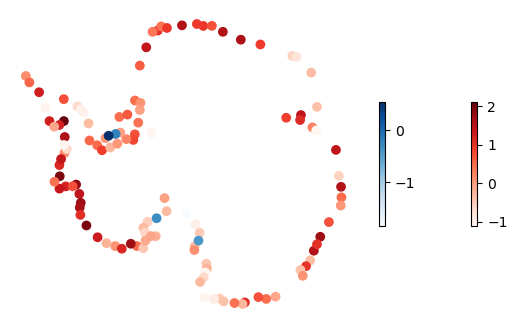

In [31]:
fig, ax = plt.subplots(1,1, figsize = (7,4))
im = [[],[]]
im[0] = plt.scatter(df_merged.x, df_merged.y, c = np.log10(-df_merged.melt_Gt), cmap = 'Reds')
im[1] = plt.scatter(df_merged.x, df_merged.y, c = np.log10(df_merged.melt_Gt), cmap = 'Blues')
ax.axis('off');
plt.colorbar(im[0], shrink = 0.4)
plt.colorbar(im[1], shrink = 0.4)
im[0].set_clim(-1.1,2.1)
#im[1].set_clim(-1.1,2.1)

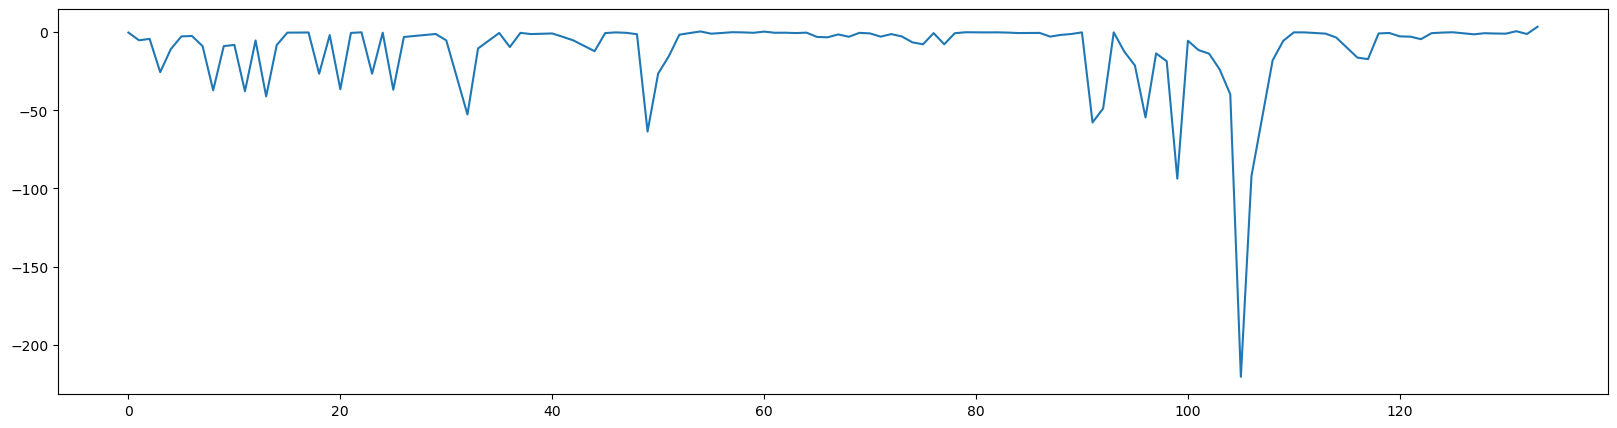

In [32]:
fig, ax = plt.subplots(1,1, figsize = (20,5))
plt.plot(melt_by_basin.basin, melt_by_basin.melt_Gt)
#plt.xlim(98,100)

In [33]:
#plt.pcolor(areas)
basins_NEMO.shape, masks.closed_cavities.shape

((439, 1440), (439, 1440))

In [34]:
areas = load_area(filepath_nemo_output)
melt_all = np.zeros_like(mask_nocavs)
melt_b = np.zeros_like(mask_nocavs)
melt_t = np.zeros_like(mask_nocavs)
CFG = xr.open_dataset(filepath_domain_CFG)
print('Putting melt back onto the ocean grid')
for kk in range(len(melt_by_basin.basin)):
    i = melt_by_basin.basin[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Calculate the top and bottom depths to inject the melt 
    # Currently using means, but might be better to use a min/max? ideally at cells touching the ocean 
    melt_b_basin = np.mean(geoms.bathymetry.values[mask_basin_cavs == 1])
    melt_t_basin = np.mean(geoms.isf_draft.values[mask_basin_cavs == 1])
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    # Should allow cells which are adjacent or as close to adjacent as possible
    if len(idx) == 1:
        for k in range(len(idx)):
            ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    elif len(idx) != 0:
        idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
        for k in range(len(idxn)):
            ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    # Redistribute the melt over the relevant cells
    # Number of pixels?
    #pixels = np.sum(ocean_edge_basin)
    # Total area covered 
    ocean_area = np.sum(areas * ocean_edge_basin).data
    # Melt per pixel?? 
    melt_per_pixel = melt_by_basin.melt_Gt[kk] * (10e12/(60*60*24*365.5)) /ocean_area
    ocean_melt = ocean_edge_basin * melt_per_pixel
    # Apply top and bottom over the relevant cells
    ocean_melt_b = ocean_edge_basin * melt_b_basin
    ocean_melt_t = ocean_edge_basin * melt_t_basin
    # Sum up the melt over all the basins
    melt_all = melt_all + ocean_melt
    melt_b = melt_b + ocean_melt_b
    melt_t = melt_t + ocean_melt_t
    print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')

You have loaded: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc
Cropped to Antarctica only
Returning area
Putting melt back onto the ocean grid


In [35]:

########## A diversion which can be deleted when you are done

In [36]:
# Are there points in the mask_bmach which are not in the domain CFG?

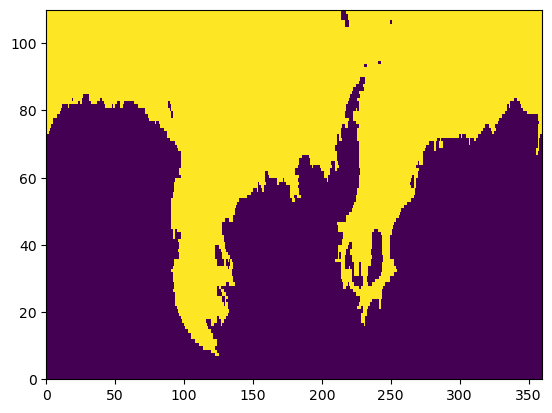

In [37]:
plt.pcolor(CFG.top_level.isel(t=0)[0:110]>0)

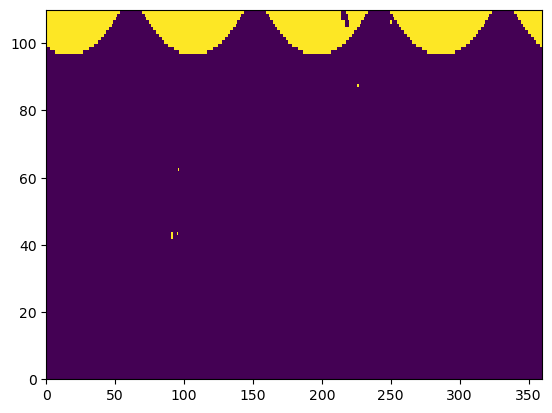

In [38]:
bmach = bmach_masks.mask_nocavs.copy()
bmach = bmach.fillna(0)
plt.pcolor(bmach !=  (CFG.top_level.isel(t=0)[0:110]>0))
#plt.colorbar()

In [39]:
###########

In [40]:
# Expanding the grid back to the NEMO eORCA1 grid
# gridT_varofint = xr.open_dataset('/ccc/work/cont003/gen6035/ockendeh/NEMO/eORCA1.L75/eORCA1.L75-I/eORCA1.4.3_CavsForNN_domain_cfg.nc')[['x','y']]
gridT_varofint = xr.open_dataset(filepath_nemo_output)[['x','y']]
min_lat = -52.2
y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
full_t   = expand_to_full_grid(melt_t,    y_trim, gridT_varofint)
full_b   = expand_to_full_grid(melt_b,    y_trim, gridT_varofint)
full_all = expand_to_full_grid(melt_all,  y_trim, gridT_varofint)

if nemo_version == '5':
    # In NEMO 5 the melt convention has changed
    # Melting is now positive and refreezing is now negative 
    print('New NEMO version (v{}), melt is positive'.format(nemo_version))
    full_all = full_all * -1 
else:
    # In NEMO 4 the melt convention is the same as in Pierre's simulations
    print('Old NEMO version (v{}), melt is negative'.format(nemo_version))
    full_all = full_all 

New NEMO version (v5), melt is positive


In [41]:
# Keep the levels unless they are outside the limits they should be? 
full_b = np.where(full_b > CFG.bathy_metry.isel(t=0).values, CFG.bathy_metry.isel(t=0).values, full_b)
full_t = np.where(full_t < CFG.isf_draft.isel(t=0).values, CFG.isf_draft.isel(t=0).values, full_t)
full_t2 = np.where(full_t > full_b, CFG.isf_draft.isel(t=0).values, full_t)
full_b = np.where(full_t > full_b, CFG.bathy_metry.isel(t=0).values, full_b)
full_t = full_t2

In [ ]:
plt.pcolor(CFG.bottom_level.isel(t=0))

In [ ]:
plt.pcolor(-np.abs(full_all)<CFG.top_level.isel(t=0).values)
plt.colorbar()

In [ ]:
plt.pcolor(full_b < full_t)

In [ ]:
# Create a netcdf dataset for the temperature and salinity profiles 
output_melt = xr.Dataset(data_vars=dict(
                                melt      = (["y", "x"], full_all.data), 
                                melt_top  = (["y", "x"], full_t.data),
                                melt_base = (["y", "x"], full_b.data),
                              ),
                   coords=dict(
                               lon = (("y", "x"), full_all.nav_lon.data),
                               lat = (("y", "x"), full_all.nav_lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network output", 
                               simulation_run = simulation, 
                               year           = year_of_interest, 
                               history        = f"{time.ctime()}: Applied neural network"),
                        )     

output_melt = output_melt.fillna(0)
print('Nan values filled')

output_melt["melt"].attrs.update({"standard_name": "Sub-shelf melt for parameterised regions",
                                  "units": "kg m-2 s-1"})
output_melt["melt_top"].attrs.update({"standard_name": "Top level to inject melt",
                                     "units": "m"})
output_melt["melt_base"].attrs.update({"standard_name": "Bottom level to inject melt",
                                     "units": "m"})
output_melt["lat"].attrs.update({"standard_name": "Latitude",
                                 "units": "degrees_north"})
output_melt["lon"].attrs.update({"standard_name": "Longitude",
                                 "units": "degrees_east"})

# Export to netcdf 
simulation = 'DUM003' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

filepath_this_nn_output = filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'
output_melt.to_netcdf(filepath_this_nn_output)
print('You have saved the nn output to:', filepath_this_nn_output)

In [ ]:
melt = xr.open_dataset(filepath_this_nn_output)# + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan
print(np.nanmax(melt_all), np.nanmin(melt_all))

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Blues')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
ax.set_ylim(0,110)

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')